## Dueling DQN для LunarLander-v3 и MountainCar-v0

In [1]:
import sys
!{sys.executable} -m pip install "gymnasium[box2d]" -q

In [2]:
import random
from collections import deque
from copy import deepcopy

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
Torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5080


In [3]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


def make_env(env_name, seed=None):
    try:
        env = gym.make(env_name)
    except Exception:
        if env_name == "LunarLander-v3":
            print("LunarLander-v3 не найден, пробую LunarLander-v2")
            env = gym.make("LunarLander-v2")
        else:
            raise

    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env


def moving_average(values, window=10):
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()


def mountain_car_potential(state):
    return 300.0 * abs(float(state[1]))


def apply_reward_shaping(env_name, state, next_state, reward, done, gamma, enabled=True):
    if not enabled:
        return reward
    if env_name != "MountainCar-v0":
        return reward

    phi_state = mountain_car_potential(state)
    phi_next = 0.0 if done else mountain_car_potential(next_state)
    return reward + gamma * phi_next - phi_state

### Replay buffer

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

### Dueling-сеть

In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        prev = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        self.features = nn.Sequential(*layers)
        self.value = nn.Linear(prev, 1)
        self.advantage = nn.Linear(prev, action_dim)

    def forward(self, x):
        features = self.features(x)
        value = self.value(features)
        advantage = self.advantage(features)
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values

### Агент Dueling DQN

In [6]:
class DuelingDQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.action_dim = action_dim
        self.gamma = config["gamma"]
        self.batch_size = config["batch_size"]
        self.target_update_freq = config["target_update_freq"]
        self.learning_starts = config["learning_starts"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_min = config["epsilon_min"]
        self.epsilon_decay = config["epsilon_decay"]

        hidden_sizes = config["hidden_sizes"]

        self.q_net = DuelingQNetwork(state_dim, action_dim, hidden_sizes).to(DEVICE)
        self.target_net = DuelingQNetwork(state_dim, action_dim, hidden_sizes).to(DEVICE)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=config["lr"])
        self.global_step = 0

    def act(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def update(self, replay_buffer):
        if len(replay_buffer) < max(self.batch_size, self.learning_starts):
            return None

        states, actions, rewards, next_states, dones = replay_buffer.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

        q_values = self.q_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1).values
            target_q = rewards + self.gamma * (1.0 - dones) * next_q

        loss = F.smooth_l1_loss(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        self.global_step += 1
        if self.global_step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

### Обучение Dueling DQN

In [7]:
def train_dueling_dqn(env_name, config, episodes=300, smoothing_window=10, verbose=True):
    set_seed(config.get("seed", SEED))
    env = make_env(env_name, seed=config.get("seed", SEED))

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DuelingDQNAgent(state_dim, action_dim, config)
    replay_buffer = ReplayBuffer(config["buffer_capacity"])

    rewards_history = []
    losses_history = []

    for episode in range(1, episodes + 1):
        state, _ = env.reset(seed=config.get("seed", SEED) + episode)
        total_reward = 0.0
        episode_losses = []

        for _ in range(config["max_steps"]):
            action = agent.act(state, explore=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            shaped_reward = apply_reward_shaping(
                env_name,
                state,
                next_state,
                reward,
                done,
                gamma=config["gamma"],
                enabled=config.get("reward_shaping", False),
            )

            replay_buffer.add(state, action, shaped_reward, next_state, done)

            loss = agent.update(replay_buffer)
            if loss is not None:
                episode_losses.append(loss)

            state = next_state
            total_reward += reward

            if done:
                break

        agent.decay_epsilon()
        rewards_history.append(total_reward)
        losses_history.append(np.mean(episode_losses) if episode_losses else np.nan)

        if verbose and (episode == 1 or episode % 20 == 0):
            avg = np.mean(rewards_history[-20:])
            print(
                f"ep={episode:03d} | R={total_reward:8.2f} | "
                f"avg20={avg:8.2f} | eps={agent.epsilon:.3f}"
            )

    env.close()

    return {
        "rewards": rewards_history,
        "ma": moving_average(rewards_history, smoothing_window),
        "losses": losses_history,
        "mean_last_20": float(np.mean(rewards_history[-20:])),
        "best_reward": float(np.max(rewards_history)),
        "config": deepcopy(config),
    }

### Эксперименты с гиперпараметрами

In [8]:
def base_dueling_config():
    return {
        "lr": 5e-4,
        "gamma": 0.99,
        "epsilon_start": 1.0,
        "epsilon_min": 0.01,
        "epsilon_decay": 0.99,
        "batch_size": 128,
        "target_update_freq": 100,
        "learning_starts": 1000,
        "hidden_sizes": (128, 128),
        "buffer_capacity": 50000,
        "max_steps": 1000,
        "reward_shaping": False,
        "seed": SEED,
    }


BEST_CONFIGS = {
    "LunarLander-v3": {
        **base_dueling_config(),
        "lr": 5e-4,
        "gamma": 0.99,
        "epsilon_min": 0.01,
        "epsilon_decay": 0.99,
        "batch_size": 128,
        "target_update_freq": 100,
        "learning_starts": 1000,
        "hidden_sizes": (128, 128),
        "buffer_capacity": 50000,
        "reward_shaping": False,
    },
    "MountainCar-v0": {
        **base_dueling_config(),
        "lr": 1e-3,
        "gamma": 0.99,
        "epsilon_min": 0.03,
        "epsilon_decay": 0.995,
        "batch_size": 128,
        "target_update_freq": 100,
        "learning_starts": 500,
        "hidden_sizes": (128, 128),
        "buffer_capacity": 50000,
        "reward_shaping": True,
    },
}

EPISODES = 1000

EPISODES_BY_ENV = {
    "LunarLander-v3": EPISODES ,
    "MountainCar-v0": EPISODES ,
}
SMOOTHING_WINDOW = 10

pd.DataFrame([
    {
        "Environment": env_name,
        "lr": cfg["lr"],
        "gamma": cfg["gamma"],
        "epsilon_start": cfg["epsilon_start"],
        "epsilon_min": cfg["epsilon_min"],
        "epsilon_decay": cfg["epsilon_decay"],
        "batch_size": cfg["batch_size"],
        "target_update_freq": cfg["target_update_freq"],
        "learning_starts": cfg["learning_starts"],
        "hidden_sizes": cfg["hidden_sizes"],
        "buffer_capacity": cfg["buffer_capacity"],
        "reward_shaping": cfg["reward_shaping"],
    }
    for env_name, cfg in BEST_CONFIGS.items()
])


,Environment,lr,gamma,epsilon_start,epsilon_min,epsilon_decay,batch_size,target_update_freq,learning_starts,hidden_sizes,buffer_capacity,reward_shaping
0,LunarLander-v3,0.0005,0.99,1.0,0.01,0.990,128,100,1000,"(128, 128)",50000,False
1,MountainCar-v0,0.0010,0.99,1.0,0.03,0.995,128,100,500,"(128, 128)",50000,True


### Финальный запуск Dueling DQN

In [9]:
all_results = {}
summary_rows = []

for env_name, config in BEST_CONFIGS.items():
    episodes = EPISODES_BY_ENV[env_name]

    print("\n" + "=" * 80)
    print(f"Окружение: {env_name}, episodes={episodes}")
    print("=" * 80)

    result = train_dueling_dqn(
        env_name,
        config,
        episodes=episodes,
        smoothing_window=SMOOTHING_WINDOW,
        verbose=True,
    )

    all_results[env_name] = result
    summary_rows.append({
        "Environment": env_name,
        "Algorithm": "Dueling DQN",
        "Mean last 20": result["mean_last_20"],
        "Best reward": result["best_reward"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values("Environment")


Окружение: LunarLander-v3, episodes=1000
ep=001 | R= -155.97 | avg20= -155.97 | eps=0.990
ep=020 | R=  -98.82 | avg20= -170.37 | eps=0.818
ep=040 | R=  -28.80 | avg20= -107.19 | eps=0.669
ep=060 | R=  -85.69 | avg20=  -69.16 | eps=0.547
ep=080 | R=  -14.41 | avg20=  -65.68 | eps=0.448
ep=100 | R=   29.15 | avg20=  -33.41 | eps=0.366
ep=120 | R=  -24.54 | avg20=   10.45 | eps=0.299
ep=140 | R=  239.55 | avg20=   63.05 | eps=0.245
ep=160 | R=  231.08 | avg20=   72.06 | eps=0.200
ep=180 | R=  272.57 | avg20=  170.01 | eps=0.164
ep=200 | R=   -4.03 | avg20=   93.56 | eps=0.134
ep=220 | R=  228.08 | avg20=  182.86 | eps=0.110
ep=240 | R=  268.57 | avg20=  222.34 | eps=0.090
ep=260 | R=  282.77 | avg20=  133.60 | eps=0.073
ep=280 | R=  271.41 | avg20=  227.10 | eps=0.060
ep=300 | R=   39.18 | avg20=  202.65 | eps=0.049
ep=320 | R=  275.67 | avg20=  260.81 | eps=0.040
ep=340 | R=  289.17 | avg20=  202.47 | eps=0.033
ep=360 | R=  282.69 | avg20=  194.75 | eps=0.027
ep=380 | R=  215.05 | avg20

,Environment,Algorithm,Mean last 20,Best reward
0,LunarLander-v3,Dueling DQN,237.831367,320.362835
1,MountainCar-v0,Dueling DQN,-149.950000,-85.000000


### Графики

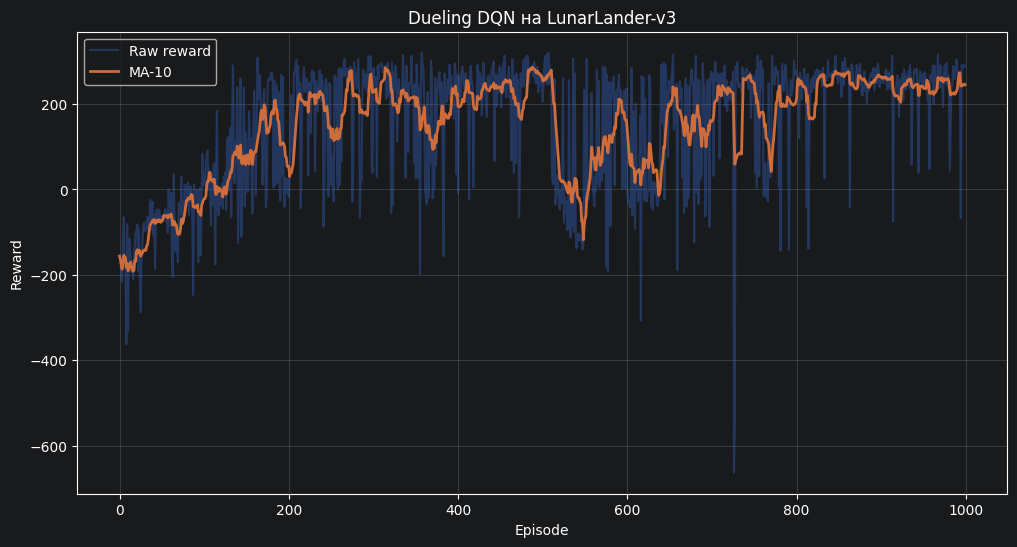

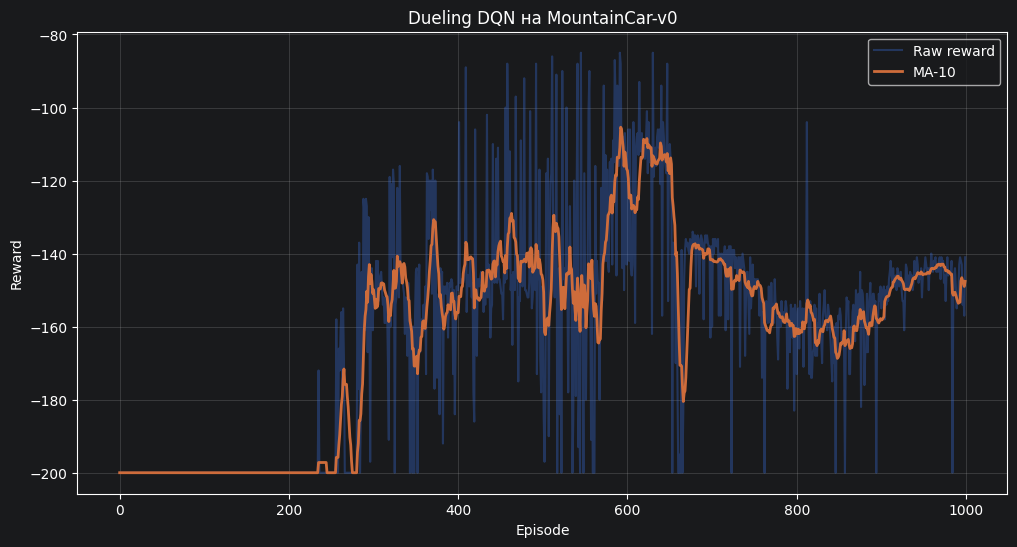

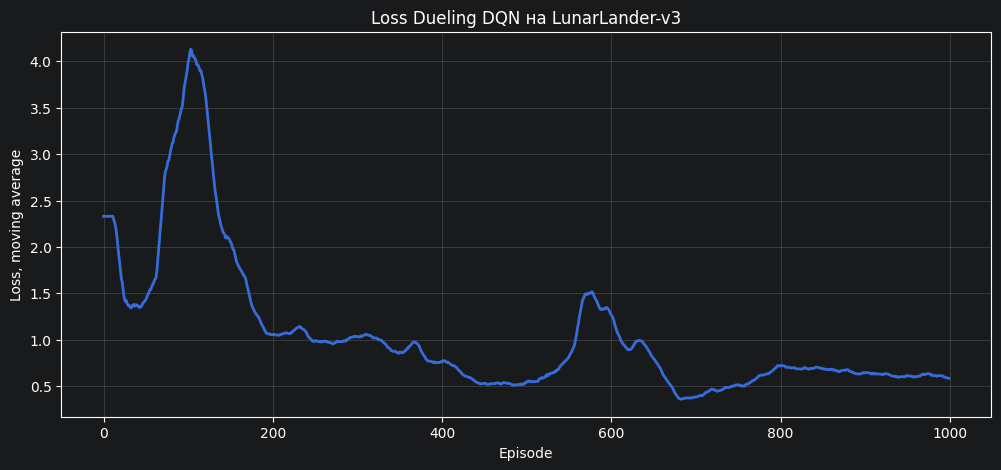

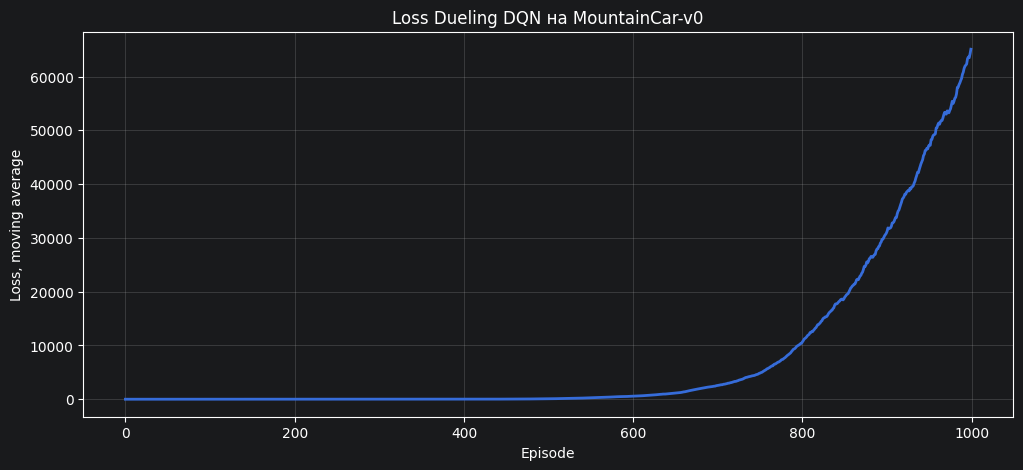

,Environment,Algorithm,Mean last 20,Best reward
0,LunarLander-v3,Dueling DQN,237.831367,320.362835
1,MountainCar-v0,Dueling DQN,-149.950000,-85.000000


In [10]:
def plot_rewards(all_results, smoothing_window=10):
    for env_name, result in all_results.items():
        plt.figure(figsize=(12, 6))
        plt.plot(result["rewards"], alpha=0.35, label="Raw reward")
        plt.plot(moving_average(result["rewards"], smoothing_window), linewidth=2, label=f"MA-{smoothing_window}")
        plt.title(f"Dueling DQN на {env_name}")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


def plot_losses(all_results, smoothing_window=10):
    for env_name, result in all_results.items():
        losses = pd.Series(result["losses"]).bfill().ffill().to_numpy()
        plt.figure(figsize=(12, 5))
        plt.plot(moving_average(losses, smoothing_window), linewidth=2)
        plt.title(f"Loss Dueling DQN на {env_name}")
        plt.xlabel("Episode")
        plt.ylabel("Loss, moving average")
        plt.grid(alpha=0.3)
        plt.show()


plot_rewards(all_results, smoothing_window=SMOOTHING_WINDOW)
plot_losses(all_results, smoothing_window=SMOOTHING_WINDOW)

summary_df.sort_values("Environment")

### Таблица итоговых гиперпараметров

In [11]:
params_rows = []
for env_name, cfg in BEST_CONFIGS.items():
    params_rows.append({
        "Environment": env_name,
        "Algorithm": "Dueling DQN",
        "lr": cfg["lr"],
        "gamma": cfg["gamma"],
        "batch_size": cfg["batch_size"],
        "epsilon_start": cfg["epsilon_start"],
        "epsilon_min": cfg["epsilon_min"],
        "epsilon_decay": cfg["epsilon_decay"],
        "target_update_freq": cfg["target_update_freq"],
        "learning_starts": cfg["learning_starts"],
        "buffer_capacity": cfg["buffer_capacity"],
        "architecture": cfg["hidden_sizes"],
        "reward_shaping": cfg.get("reward_shaping", False),
    })

params_df = pd.DataFrame(params_rows)
params_df

,Environment,Algorithm,lr,gamma,batch_size,epsilon_start,epsilon_min,epsilon_decay,target_update_freq,learning_starts,buffer_capacity,architecture,reward_shaping
0,LunarLander-v3,Dueling DQN,0.0005,0.99,128,1.0,0.01,0.990,100,1000,50000,"(128, 128)",False
1,MountainCar-v0,Dueling DQN,0.0010,0.99,128,1.0,0.03,0.995,100,500,50000,"(128, 128)",True
